In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


In [111]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["order_date", "ship_date"]
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,day_name,week,day,shipping_days,sales_per_unit,profit_per_unit,discount_amount,profit_status,profit_margin,order_value
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,130.9800,20.9568,0.000000,Profit,16.00,261.9600
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Tuesday,45,8,3,243.9800,73.1940,0.000000,Profit,30.00,731.9400
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Sunday,23,12,4,7.3100,3.4357,0.000000,Profit,47.00,14.6200
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,191.5155,-76.6062,430.909875,Loss,-40.00,957.5775
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Sunday,41,11,7,11.1840,1.2582,4.473600,Profit,11.25,22.3680


# 1. Which customers generated the highest sales? (Top 10)

In [112]:
top_customers  = (df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10).reset_index())
top_customers 

,customer_name,sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


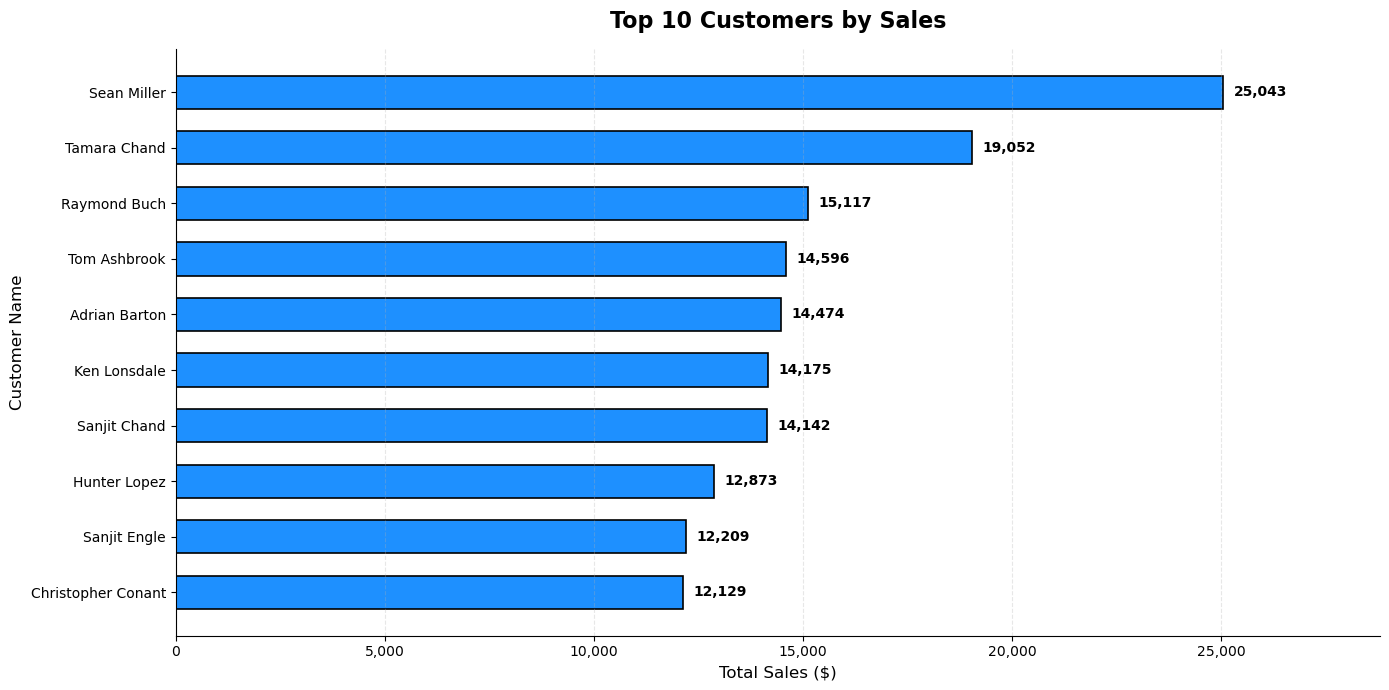

In [113]:

plt.figure(figsize=(14,7))

bars = plt.barh(top_customers["customer_name"], top_customers["sales"],
         color="dodgerblue", edgecolor="black",
         linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Sales ($)", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x",linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, top_customers["sales"].max() * 1.15)

# Format X-axis
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

# Value labels
offset = top_customers["sales"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="left",
        fontsize=10, fontweight="bold"
    )


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_sales.png",dpi=300, bbox_inches="tight"
) 
plt.show()



## Insight
- A few customers generated very high sales.
- These customers are the company's most valuable customers.
- The company should focus on retaining these customers.

# 2. Which customers generated the highest profit? (Top 10)

In [114]:
top10_customers_by_profit = (df.groupby("customer_name")["profit"].sum().sort_values(ascending=False).head(10).reset_index())
top10_customers_by_profit

,customer_name,profit
0,Tamara Chand,8981.3239
1,Raymond Buch,6976.0959
2,Sanjit Chand,5757.4119
3,Hunter Lopez,5622.4292
4,Adrian Barton,5444.8055
5,Tom Ashbrook,4703.7883
6,Christopher Martinez,3899.8904
7,Keith Dawkins,3038.6254
8,Andy Reiter,2884.6208
9,Daniel Raglin,2869.0760


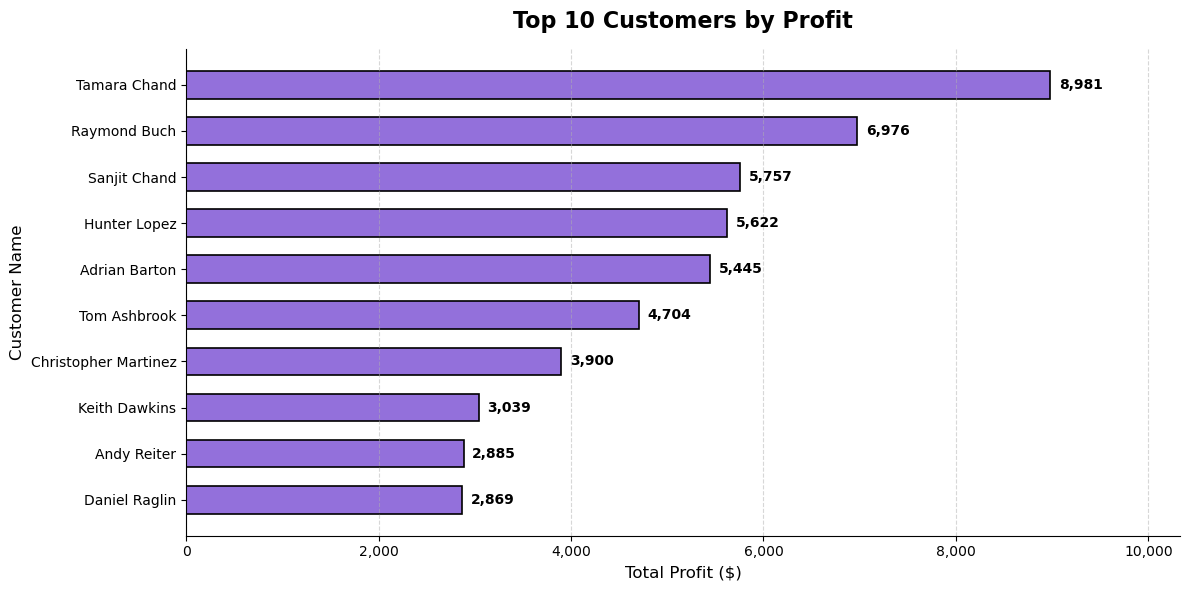

In [115]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_customers_by_profit["customer_name"], top10_customers_by_profit["profit"], color="mediumpurple", edgecolor="black", linewidth=1.2, height=0.6)

plt.gca().invert_yaxis()

plt.title("Top 10 Customers by Profit", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit ($)", fontsize=12)

plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.xlim(0, top10_customers_by_profit["profit"].max() * 1.15)

# Format X-axis
plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

offset = top10_customers_by_profit["profit"].max() * 0.01

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", 
        fontsize=10, fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_profit.png",dpi=300, bbox_inches="tight"
)


plt.show()

## Insight
- Some customers generate much higher profit than others.
- High-profit customers are important for business growth.
- The company should maintain strong relationships with these customers.

# 3. Which customers generated the highest loss?

In [116]:
top10_loss_customers = (df.groupby("customer_name")["profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_loss_customers

,customer_name,profit
0,Cindy Stewart,-6626.3895
1,Grant Thornton,-4108.6589
2,Luke Foster,-3583.9770
3,Sharelle Roach,-3333.9144
4,Henry Goldwyn,-2797.9635
5,Nathan Cano,-2204.8072
6,Sean Braxton,-2082.7451
7,Sean Miller,-1980.7393
8,Christine Phan,-1850.3029
9,Natalie Fritzler,-1695.9714


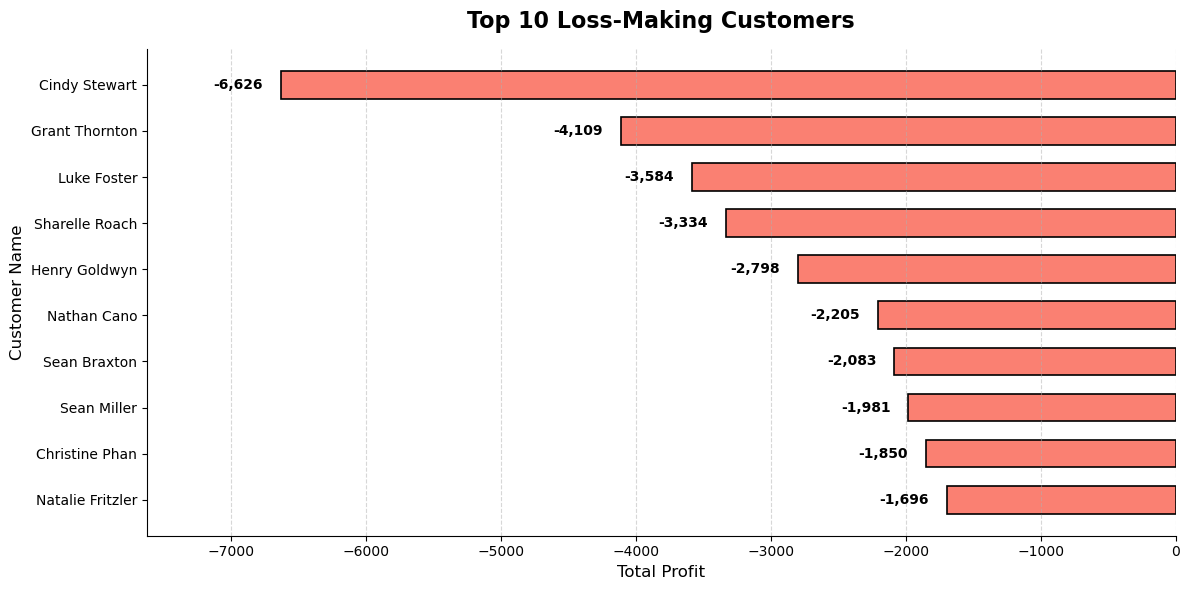

In [117]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_loss_customers["customer_name"], top10_loss_customers["profit"],
         color="salmon",
         linewidth=1.2,
         edgecolor="black",
         height=0.6
)

plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Customers", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Total Profit", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Extra Space for labels
plt.xlim(top10_loss_customers["profit"].min() * 1.15,0)

offset = abs(top10_loss_customers["profit"].min()) * 0.02

for bar in bars:
    plt.text(
        bar.get_width() - offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center", ha="right",
        fontsize=10,
        fontweight="bold"
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_loss_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some customers generated a negative profit.
- High discounts or expensive shipping may be the reason.
- These customers should be analyzed to reduce future losses.

# 4. Which customers generated the highest number of orders? (Top 10)

In [118]:
top10_customers_orders = (
    df.groupby("customer_name")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top10_customers_orders.columns = ["customer_name", "total_orders"]

top10_customers_orders 

,customer_name,total_orders
0,William Brown,37
1,John Lee,34
2,Matt Abelman,34
3,Paul Prost,34
4,Chloris Kastensmidt,32
5,Seth Vernon,32
6,Edward Hooks,32
7,Jonathan Doherty,32
8,Arthur Prichep,31
9,Emily Phan,31


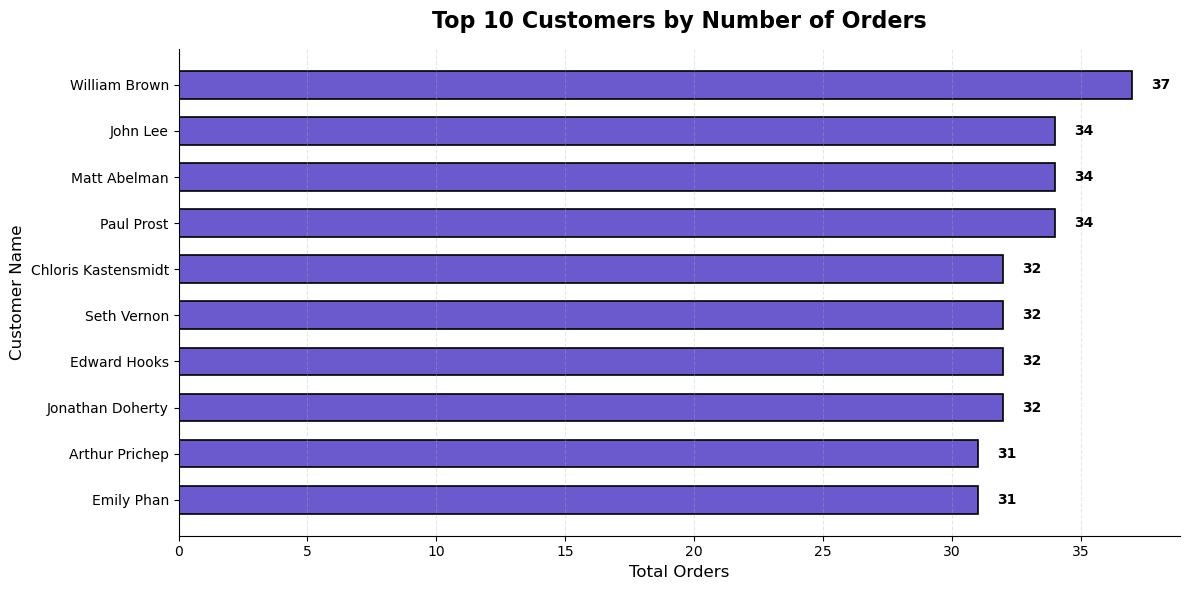

In [119]:

plt.figure(figsize=(12,6))

bars = plt.barh(
    top10_customers_orders["customer_name"],
    top10_customers_orders["total_orders"],
    color="slateblue",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

# Highest orders at top
plt.gca().invert_yaxis()

plt.title(
    "Top 10 Customers by Number of Orders",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Orders", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Value Labels
offset = top10_customers_orders["total_orders"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_customers_by_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some customers place orders very frequently.
- Frequent customers are loyal customers.
- Reward programs can help retain these customers.

# 5. Which region has the highest number of customers?

In [120]:
region_customers = (
    df.groupby("region")["customer_name"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index()
)

region_customers.columns = ["region", "total_customers"]

region_customers

,region,total_customers
0,West,686
1,East,674
2,Central,629
3,South,512


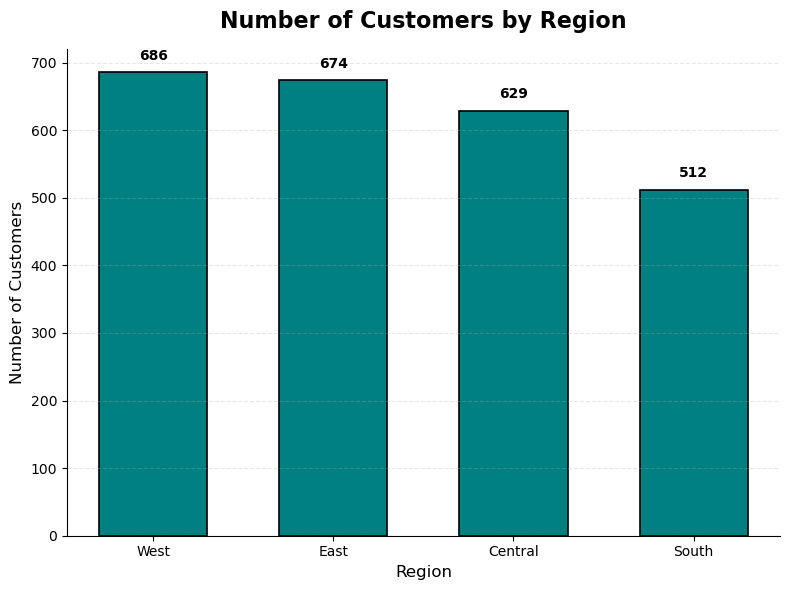

In [121]:

plt.figure(figsize=(8,6))

bars = plt.bar(
    region_customers["region"],
    region_customers["total_customers"],
    color="teal",
    edgecolor="black",
    linewidth=1.2,
    width=0.6
)

plt.title(
    "Number of Customers by Region",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Region", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Value Labels
offset = region_customers["total_customers"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + offset,
        f"{int(bar.get_height())}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Remove Top & Right Border
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customers_by_region.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Customer numbers are different across regions.
- The region with the highest customer count has the largest market.
- Regions with fewer customers have growth opportunities.

# 6. Which customer segment generated the highest profit?

In [122]:
segment_profit = (df.groupby("segment")["profit"].sum().sort_values(ascending=False).reset_index())
segment_profit

,segment,profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


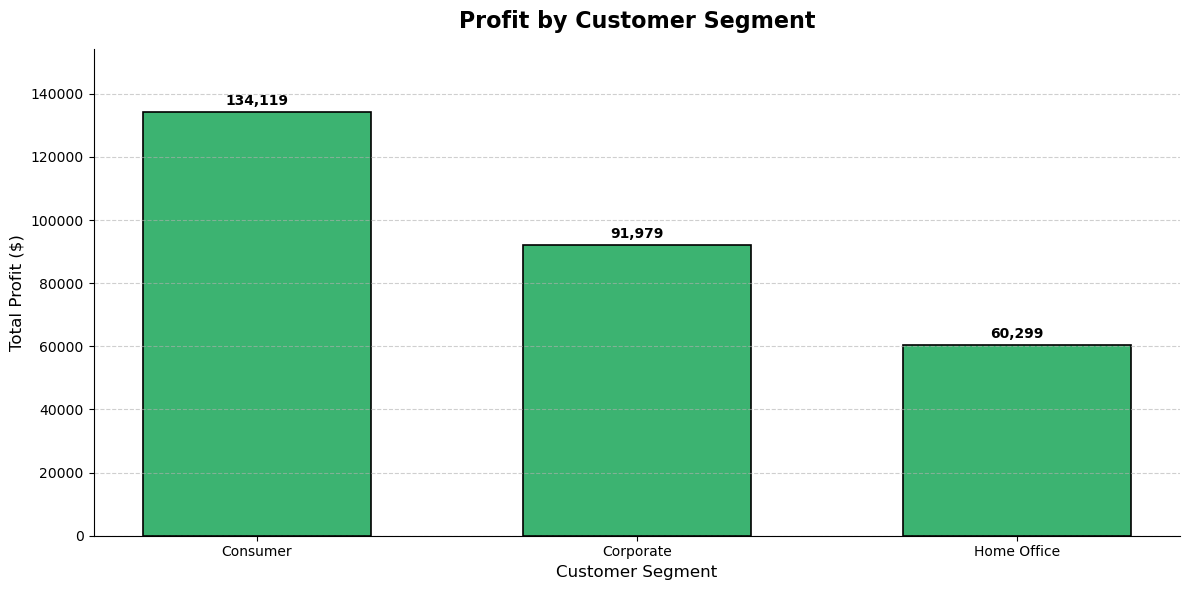

In [123]:
plt.figure(figsize=(12,6))

bars = plt.bar(segment_profit["segment"], segment_profit["profit"],
        color="mediumseagreen", edgecolor="black", linewidth=1.2, width=0.6)

plt.title("Profit by Customer Segment", fontsize=16, fontweight="bold", pad=15)

plt.xlabel("Customer Segment", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0, segment_profit["profit"].max() * 1.15)

offset = segment_profit["profit"].max() * 0.01

for bar in bars:
        plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + offset,
                f"{bar.get_height():,.0f}",
                ha="center", va="bottom",
                fontsize=10, fontweight="bold"
        )
        
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
        "../visualizations/customers/customer_segment_profits.png",
        dpi=300, 
        bbox_inches="tight"
)

plt.show()

## Insight
- Customer segments contribute different amounts of profit.
- One segment generates the highest overall profit.
- The company should focus more on the most profitable segment.

# 7. What percentage of customers belong to each segment?

In [124]:
segment_percentage = (
    df.groupby("segment")["customer_name"]
    .nunique()
    .reset_index(name="total_customers")
)


segment_percentage["percentage"] = (
    segment_percentage["total_customers"]/
    segment_percentage["total_customers"].sum()

) * 100

segment_percentage


,segment,total_customers,percentage
0,Consumer,409,51.576293
1,Corporate,236,29.760404
2,Home Office,148,18.663304


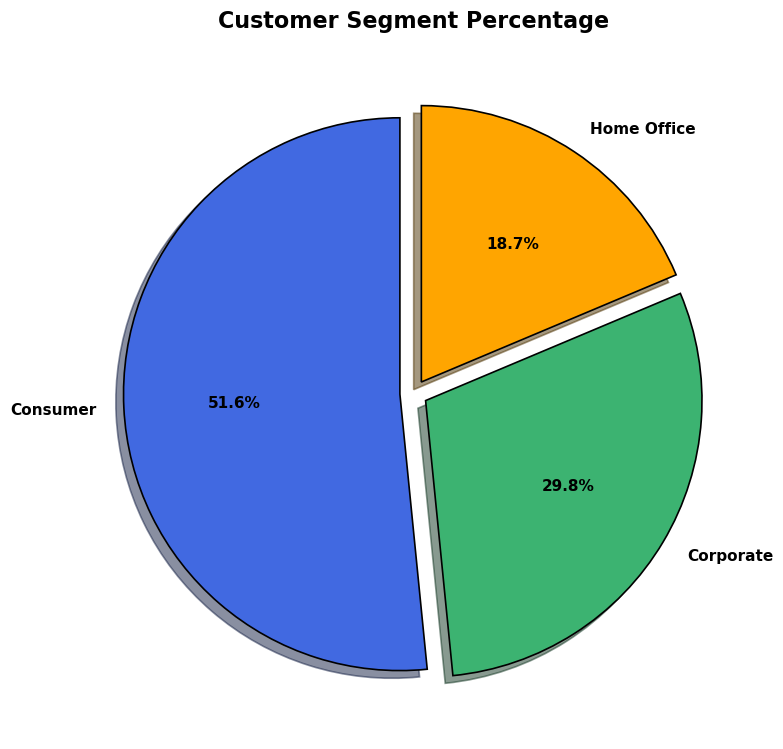

In [ ]:
plt.figure(figsize=(8,8))

colors = ["royalblue", "mediumseagreen", "orange"]

explode = [0.05] * len(segment_percentage)

plt.pie(
    segment_percentage["percentage"],
    labels=segment_percentage["segment"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True,
    wedgeprops={
        "edgecolor":"black",
        "linewidth":1.2
    },
    textprops={
        "fontsize":11,
        "fontweight":"bold"
    }
)

plt.title(
    "Customer Segment Percentage",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_segment_percentage.png",
    dpi=300,
    bbox_inches="tight"
)
=
plt.show()

## Insight
- The pie chart shows how customers are divided among segments.
- One segment has the largest customer base.
- This helps understand the customer distribution.

# 8. What is the distribution of customer sales? Histogram + KDE

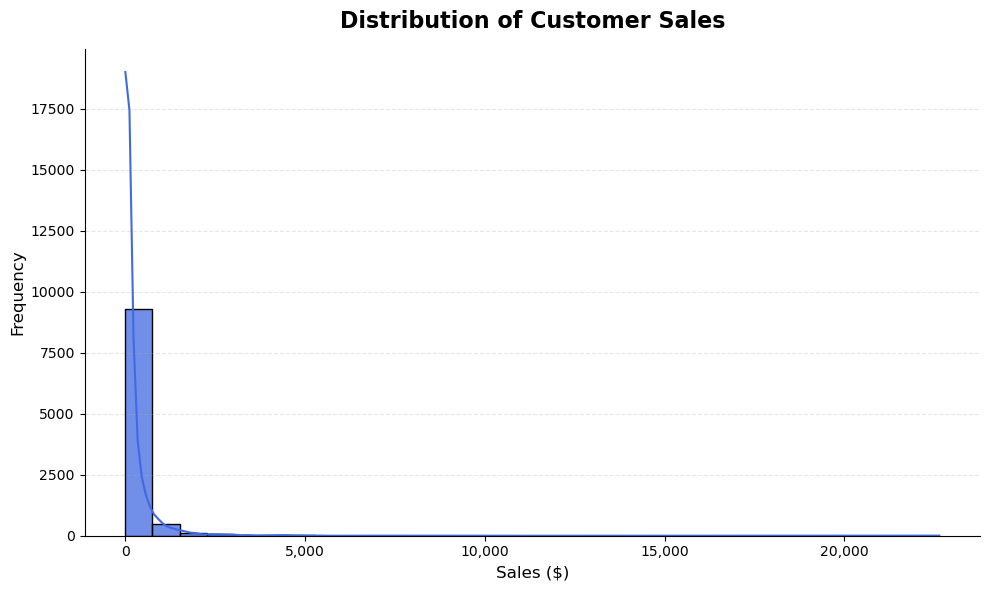

In [126]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="sales",
    bins=30,
    kde=True,
    color="royalblue",
    edgecolor="black",
    alpha=0.75
)

plt.title(
    "Distribution of Customer Sales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sales ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_sales_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Most customer orders have low to medium sales.
- Only a few orders have very high sales.
- This indicates that high-value orders are less common.

# 9. What is the relationship between customer sales and profit?

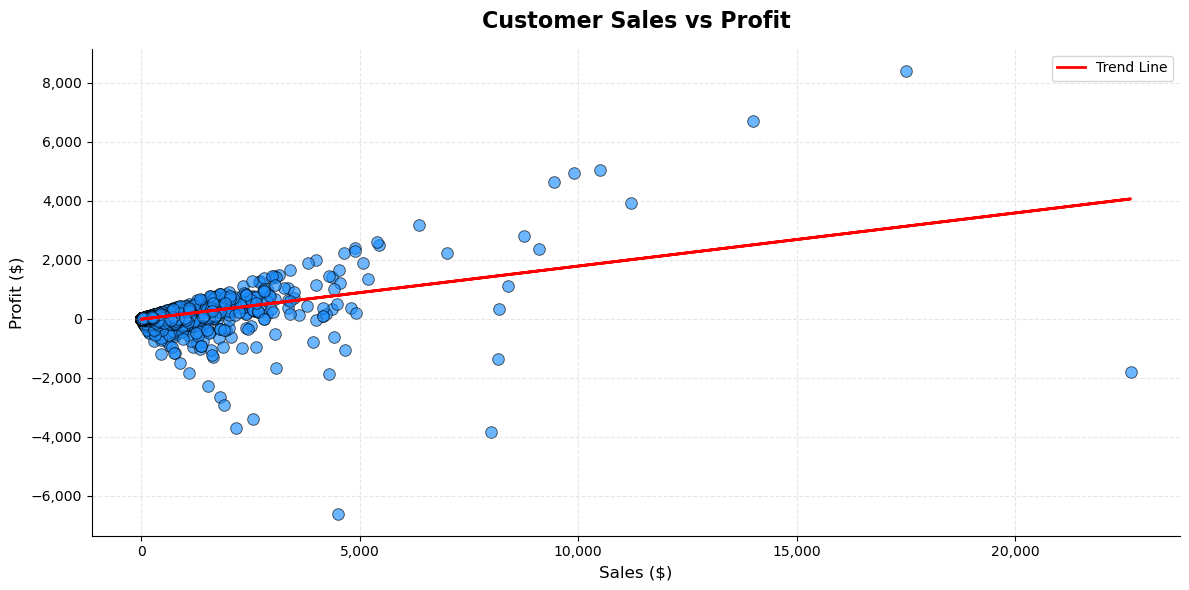

In [127]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit",
    color="dodgerblue",
    edgecolor="black",
    s=70,
    alpha=0.65
)

# Trend Line
z = np.polyfit(df["sales"], df["profit"], 1)
p = np.poly1d(z)

plt.plot(
    df["sales"],
    p(df["sales"]),
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title(
    "Customer Sales vs Profit",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Sales ($)", fontsize=12)
plt.ylabel("Profit ($)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()

plt.gca().xaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().yaxis.set_major_formatter(
    mticker.StrMethodFormatter("{x:,.0f}")
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/customer_sales_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Higher sales do not always mean higher profit.
- Some high-sales orders still generate low profit.
- Discounts and costs may reduce profitability.

# 10. Which states have the highest number of customers?

In [128]:
state_customers = (
    df.groupby("state")["customer_name"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="total_customers")
)
state_customers

,state,total_customers
0,California,577
1,New York,415
2,Texas,370
3,Pennsylvania,257
4,Illinois,237
5,Washington,224
6,Ohio,202
7,Florida,181
8,North Carolina,122
9,Virginia,107


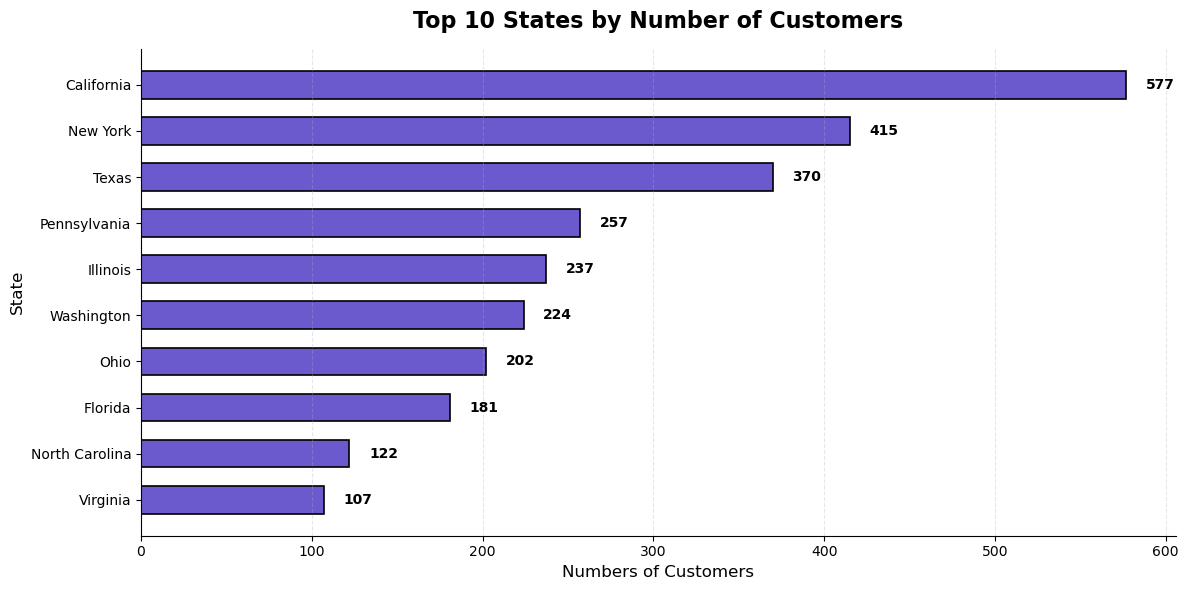

In [129]:
plt.figure(figsize=(12,6))

bars = plt.barh(
    state_customers["state"],
    state_customers["total_customers"],
    color="slateblue",
    edgecolor="black",
    linewidth=1.2,
    height=0.6
)

plt.gca().invert_yaxis()

plt.title(
    "Top 10 States by Number of Customers",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Numbers of Customers", fontsize=12)
plt.ylabel("State", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

offset = state_customers["total_customers"].max() * 0.02

for bar in bars:
    plt.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )
    
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../visualizations/customers/top10_states_by_customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight
- Some states have many more customers than others.
- These states are important markets for the company.
- Marketing efforts can focus on high-customer states.